In [1]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error
import os
os.makedirs('figures', exist_ok = True)

test = pd.read_csv('data/interim/test_residuals.csv', index_col = 0)
m2 = pd.read_csv('data/interim/model2_test_predictions.csv', index_col = 0)
pipe = joblib.load('model1_pipe.pkl')


In [2]:
X_test_log = np.log10(test[['Adult weight (g)']])
y_test_log = np.log10(test['Maximum longevity (yrs)'])


In [3]:
m1_pred_subset = pipe.predict(X_test_log.loc[m2.index])

y2_pred_test = m2['y2_pred_test'].values

combined_pred = m1_pred_subset + y2_pred_test

y_true_subset = y_test_log.loc[m2.index]
mae_combined = mean_absolute_error(y_true_subset, combined_pred)

print(f'No. of Species in subset for Two-stage model: {len(y_true_subset)}')
print(f'Two-stage model R² score: {r2_score(y_true_subset, combined_pred):.3f}')
print(f'Two-stage model MAE: {mae_combined:.3f}')
print(f'Two-stage model final predictions lie within a factor of {10**mae_combined:.2f} of true values')

No. of Species in subset for Two-stage model: 59
Two-stage model R² score: 0.733
Two-stage model MAE: 0.128
Two-stage model final predictions lie within a factor of 1.34 of true values


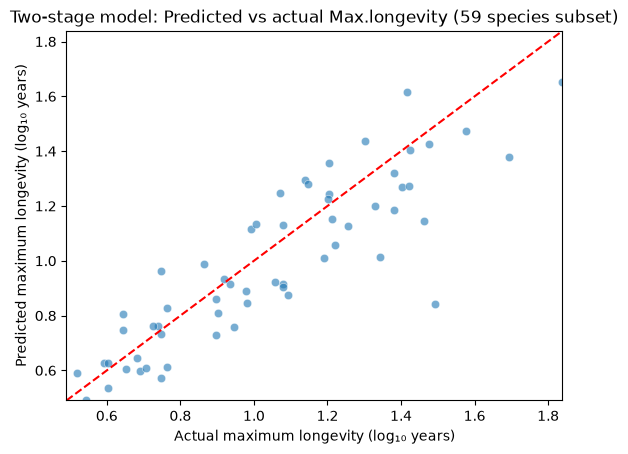

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = y_true_subset, y = combined_pred, alpha = 0.6)

plot2_min = min(y_true_subset.min(), combined_pred.min())
plot2_max = max(y_true_subset.max(), combined_pred.max())
plt.plot([plot2_min, plot2_max], [plot2_min, plot2_max], color = 'red', linestyle = '--')
plt.xlim(plot2_min, plot2_max)
plt.ylim(plot2_min, plot2_max)

plt.xlabel('Actual maximum longevity (log₁₀ years)')
plt.ylabel('Predicted maximum longevity (log₁₀ years)')
plt.title('Two-stage model: Predicted vs actual Max.longevity (59 species subset)')
plt.savefig('figures/combined_pipeline_plot.png', dpi = 150)
plt.show()